In [25]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# ds = xr.open_dataset(r"D://Niharika Work//Climate_Project//CERES_EBAF-TOA_Edition4.1-20260303_075023//CERES_EBAF-TOA_Edition4.1_200003-202203.nc")

In [ ]:
# print(ds)

<xarray.Dataset> Size: 792MB
Dimensions:                        (lon: 360, lat: 180, ctime: 12, sc: 2,
                                    time: 265)
Coordinates:
  * lon                            (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                            (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * ctime                          (ctime) int32 48B 1 2 3 4 5 6 7 8 9 10 11 12
  * time                           (time) datetime64[ns] 2kB 2000-03-15 ... 2...
Dimensions without coordinates: sc
Data variables: (12/67)
    climatology_bounds             (ctime, sc) int32 96B ...
    toa_sw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_lw_all_mon                 (time, lat, lon) float32 69MB ...
    toa_net_all_mon                (time, lat, lon) float32 69MB ...
    toa_sw_clr_c_mon               (time, lat, lon) float32 69MB ...
    toa_lw_clr_c_mon               (time, lat, lon) float32 69MB ...
    ...                             ...
    gtoa_n

In [26]:
path = "D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//"

ds_rsdt = xr.open_dataset(path + "rsdt_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")
ds_rsut = xr.open_dataset(path + "rsut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")
ds_rlut = xr.open_dataset(path + "rlut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")

In [27]:
print(ds_rsdt)

<xarray.Dataset> Size: 163MB
Dimensions:      (lat: 143, lon: 144, time: 1980, axis_nbounds: 2)
Coordinates:
  * lat          (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon          (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time         (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-1...
Dimensions without coordinates: axis_nbounds
Data variables:
    time_bounds  (time, axis_nbounds) datetime64[ns] 32kB ...
    rsdt         (time, lat, lon) float32 163MB ...
Attributes: (12/51)
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2018-07-11T07:36:41Z
    tracking_id:            hdl:21.14100/5d2ee046-5f07-47c6-84af-e8f4a83f7684
    description:            CMIP6 historical
    title:                  IPSL-CM6A-LR model output prepared for CMIP6 / CM...
    activity_id:            CMIP
    ...                     ...
    name:                   /ccc/work/cont003/gencmip6/p86caub/IGCM_OUT/IPSLC...
    further_inf

In [28]:
rsdt = ds_rsdt.rsdt.sel(time=slice("2001","2014"))
rsut = ds_rsut.rsut.sel(time=slice("2001","2014"))
rlut = ds_rlut.rlut.sel(time=slice("2001","2014"))

### Compute TOA Net Radiation

In [29]:
toa_net = rsdt - rsut - rlut

### Area-weighted global mean

In [30]:
weights = np.cos(np.deg2rad(toa_net.lat))

toa_global = toa_net.weighted(weights).mean(("lat","lon"))

### Plot spatial mean map

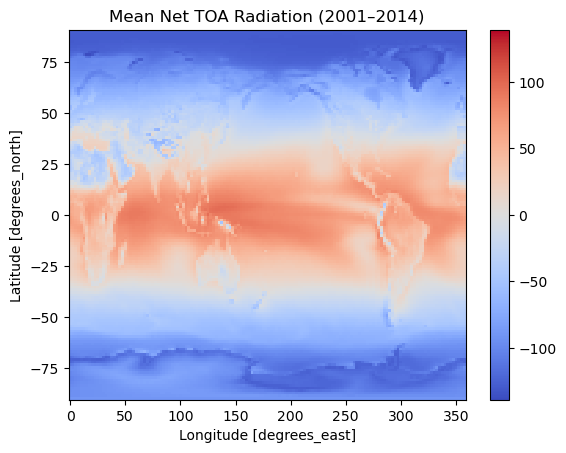

In [31]:
toa_net.mean("time").plot(cmap="coolwarm")
plt.title("Mean Net TOA Radiation (2001–2014)")
plt.show()

In [ ]:
# # print(toa_net.mean().values)

import numpy as np

weights = np.cos(np.deg2rad(rsdt.lat))
weights.name = "weights"

toa_net_mean = toa_net.mean("time")

toa_net_global = toa_net.weighted(weights).mean(("lat","lon"))

print(toa_net_global.mean().values)

1.3788512


In [32]:
# import matplotlib.pyplot as plt

# toa_net_mean = toa_net.mean("time")

# plt.figure(figsize=(10,5))
# toa_net_mean.plot(cmap="coolwarm")
# plt.title("Net TOA Radiation (IPSL-CM6A-LR, 2001–2014)")
# plt.show()

### Compute Cloud Radiative Effect

In [33]:
rsutcs = xr.open_dataset(path+"rsutcs_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")['rsutcs']
rlutcs = xr.open_dataset(path+"rlutcs_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")['rlutcs']

rsutcs = rsutcs.sel(time=slice("2001","2014"))
rlutcs = rlutcs.sel(time=slice("2001","2014"))

sw_cre = rsutcs - rsut
lw_cre = rlutcs - rlut
net_cre = sw_cre + lw_cre

print()

### Plot CRE map

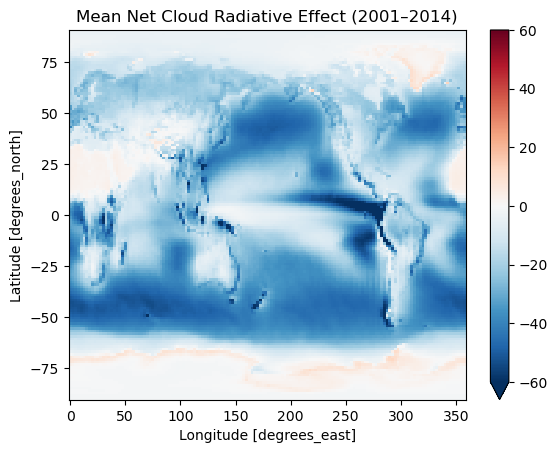

In [36]:
# net_cre.mean("time").plot()
net_cre.mean("time").plot(
    cmap="RdBu_r",
    vmin=-60,
    vmax=60
)

plt.title("Mean Net Cloud Radiative Effect (2001–2014)")
plt.show()

In [15]:
print(ds_rsdt)

<xarray.Dataset> Size: 163MB
Dimensions:      (lat: 143, lon: 144, time: 1980, axis_nbounds: 2)
Coordinates:
  * lat          (lat) float32 572B -90.0 -88.73 -87.46 ... 87.46 88.73 90.0
  * lon          (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time         (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-1...
Dimensions without coordinates: axis_nbounds
Data variables:
    time_bounds  (time, axis_nbounds) datetime64[ns] 32kB ...
    rsdt         (time, lat, lon) float32 163MB ...
Attributes: (12/51)
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2018-07-11T07:36:41Z
    tracking_id:            hdl:21.14100/5d2ee046-5f07-47c6-84af-e8f4a83f7684
    description:            CMIP6 historical
    title:                  IPSL-CM6A-LR model output prepared for CMIP6 / CM...
    activity_id:            CMIP
    ...                     ...
    name:                   /ccc/work/cont003/gencmip6/p86caub/IGCM_OUT/IPSLC...
    further_inf

In [37]:
weights = np.cos(np.deg2rad(net_cre.lat))

net_cre_global = net_cre.weighted(weights).mean(("lat","lon"))

print(net_cre_global.mean().values)

-24.097895


In [ ]:
# rsdt = ds_rsdt['rsdt'].sel(time=slice("2001-01-01","2014-12-31"))

# print(rsdt)

<xarray.DataArray 'rsdt' (time: 168, lat: 143, lon: 144)> Size: 14MB
[3459456 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 572B -90.0 -88.73 -87.46 -86.2 ... 87.46 88.73 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1kB 2001-01-16T12:00:00 ... 2014-12-16T12:...
Attributes:
    long_name:           TOA Incident Shortwave Radiation
    units:               W m-2
    online_operation:    average
    cell_methods:        area: time: mean
    interval_operation:  900 s
    interval_write:      1 month
    standard_name:       toa_incoming_shortwave_flux
    description:         at the top of the atmosphere
    positive:            down
    history:             none
    cell_measures:       area: areacella


In [ ]:
# ds_rsut = xr.open_dataset("D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rsut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")
# ds_rlut = xr.open_dataset("D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rlut_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")

# rsut = ds_rsut['rsut'].sel(time=slice("2001-01-01","2014-12-31"))
# rlut = ds_rlut['rlut'].sel(time=slice("2001-01-01","2014-12-31"))

In [ ]:
# toa_net = rsdt - rsut - rlut

In [ ]:
# # toa_net.mean().values

# import numpy as np

# weights = np.cos(np.deg2rad(rsdt.lat))
# weights.name = "weights"

# toa_net_mean = toa_net.mean("time")

# toa_net_global = toa_net.weighted(weights).mean(("lat","lon"))

# print(toa_net_global.mean().values)

1.3788512


In [ ]:
# import matplotlib.pyplot as plt

# toa_net.mean(("lat","lon")).plot()
# plt.title("Global Mean Net TOA Radiation (2001–2014)")
# plt.ylabel("W/m²")
# plt.show()

## Compute Cloud Radiative Effect

In [ ]:
# rsutcs = xr.open_dataset("D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rsutcs_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")['rsutcs']
# rlutcs = xr.open_dataset("D://Niharika Work//Climate_Project//CMIP6//IPSL_historical//rlutcs_Amon_IPSL-CM6A-LR_historical_r1i1p1f1_gr_185001-201412.nc")['rlutcs']

# rsutcs = rsutcs.sel(time=slice("2001-01-01","2014-12-31"))
# rlutcs = rlutcs.sel(time=slice("2001-01-01","2014-12-31"))

In [ ]:
# sw_cre = rsutcs - rsut
# lw_cre = rlutcs - rlut
# net_cre = sw_cre + lw_cre

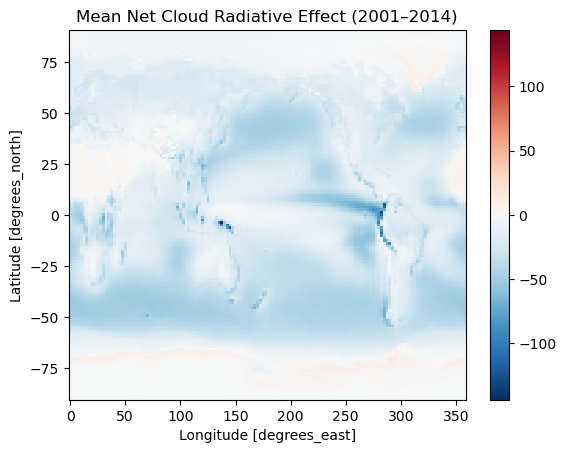

In [ ]:
# net_cre.mean("time").plot()
# plt.title("Mean Net Cloud Radiative Effect (2001–2014)")
# plt.show()

### Code for Zonal Mean

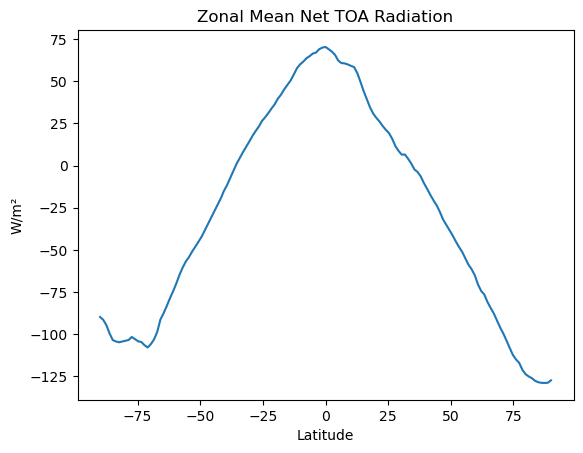

In [35]:
zonal_mean = toa_net.mean("time").mean("lon")

zonal_mean.plot()
plt.title("Zonal Mean Net TOA Radiation")
plt.xlabel("Latitude")
plt.ylabel("W/m²")
plt.show()

In [39]:
import xarray as xr

path_future = "D://Niharika Work//Climate_Project//CMIP6//IPSL_ssp585//"

rsdt_future = xr.open_mfdataset(path_future + "rsdt*.nc", use_cftime=True)['rsdt']
rsut_future = xr.open_mfdataset(path_future + "rsut*.nc", use_cftime=True)['rsut']
rlut_future = xr.open_mfdataset(path_future + "rlut*.nc", use_cftime=True)['rlut']

C:\Users\shubh\AppData\Local\Temp\ipykernel_2404\546407538.py:5: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsdt_future = xr.open_mfdataset(path_future + "rsdt*.nc", use_cftime=True)['rsdt']
C:\Users\shubh\AppData\Local\Temp\ipykernel_2404\546407538.py:5: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  rsdt_future = xr.open_mfdataset(path_future + "rsdt*.nc", use_cftime=True)['rsdt']
C:\Users\shubh\AppData\Local\Temp\ipykernel_2404\546407538.py:6: DeprecationWarning: Usage of 'u

In [40]:
print(rsdt_future)

<xarray.DataArray 'rsdt' (time: 3432, lat: 143, lon: 144)> Size: 283MB
dask.array<concatenate, shape=(3432, 143, 144), dtype=float32, chunksize=(1, 143, 144), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 572B -90.0 -88.73 -87.46 -86.2 ... 87.46 88.73 90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) object 27kB 2015-01-16 12:00:00 ... 2300-12-16 12:00:00
Attributes:
    long_name:           TOA Incident Shortwave Radiation
    units:               W m-2
    online_operation:    average
    cell_methods:        area: time: mean
    interval_operation:  900 s
    interval_write:      1 month
    standard_name:       toa_incoming_shortwave_flux
    description:         at the top of the atmosphere
    positive:            down
    history:             none
    cell_measures:       area: areacella


In [41]:
rsdt_future = rsdt_future.sel(time=slice("2081","2100"))
rsut_future = rsut_future.sel(time=slice("2081","2100"))
rlut_future = rlut_future.sel(time=slice("2081","2100"))

In [43]:
print(rsdt_future.time[0])
print(rsdt_future.time[-1])

<xarray.DataArray 'time' ()> Size: 8B
array(cftime.DatetimeGregorian(2081, 1, 16, 12, 0, 0, 0, has_year_zero=False),
      dtype=object)
Coordinates:
    time     object 8B 2081-01-16 12:00:00
Attributes:
    axis:           T
    standard_name:  time
    long_name:      Time axis
    time_origin:    2015-01-01 00:00:00
    bounds:         time_bounds
<xarray.DataArray 'time' ()> Size: 8B
array(cftime.DatetimeGregorian(2100, 12, 16, 12, 0, 0, 0, has_year_zero=False),
      dtype=object)
Coordinates:
    time     object 8B 2100-12-16 12:00:00
Attributes:
    axis:           T
    standard_name:  time
    long_name:      Time axis
    time_origin:    2015-01-01 00:00:00
    bounds:         time_bounds


In [42]:
toa_net_future = rsdt_future - rsut_future - rlut_future

In [ ]:
rsutcs_future = xr.open_mfdataset(path_future + "rsutcs*.nc")['rsutcs']
rlutcs_future = xr.open_mfdataset(path_future + "rlutcs*.nc")['rlutcs']

rsutcs_future = rsutcs_future.sel(time=slice("2081","2100"))
rlutcs_future = rlutcs_future.sel(time=slice("2081","2100"))

sw_cre_future = rsutcs_future - rsut_future
lw_cre_future = rlutcs_future - rlut_future
net_cre_future = sw_cre_future + lw_cre_future